#Exercise.
Implement an End to End CNN Model for Image Classification Task.

Objective

In this exercise, you will build and train a Convolutional Neural Network to classify fruits in Amazon using TensorFlow and Keras.

## Task 1: Data Understanding and Visualization:
Download the Provided Data and Complete the following task.

1. Load and visualize images from a dataset stored in directories, where each subdirec-
tory represents a class. You are expected to write a code:


  * Get the list of class directories from the train folder.

  * Select one image randomly from each class.

  * Display the images in a grid format with two rows using matplotlib.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras import layers
from sklearn.metrics import classification_report

In [ ]:
# Define dataset paths
train_dir = "/content/drive/MyDrive/Dataset/FruitinAmazon/train/"
test_dir = "/content/drive/MyDrive/Dataset/FruitinAmazon/test/"

In [ ]:
img_height = 128 # Example image height
img_width = 128  # Example image width
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation

# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]

# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False, # Validation sets generally don't need to be shuffled
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


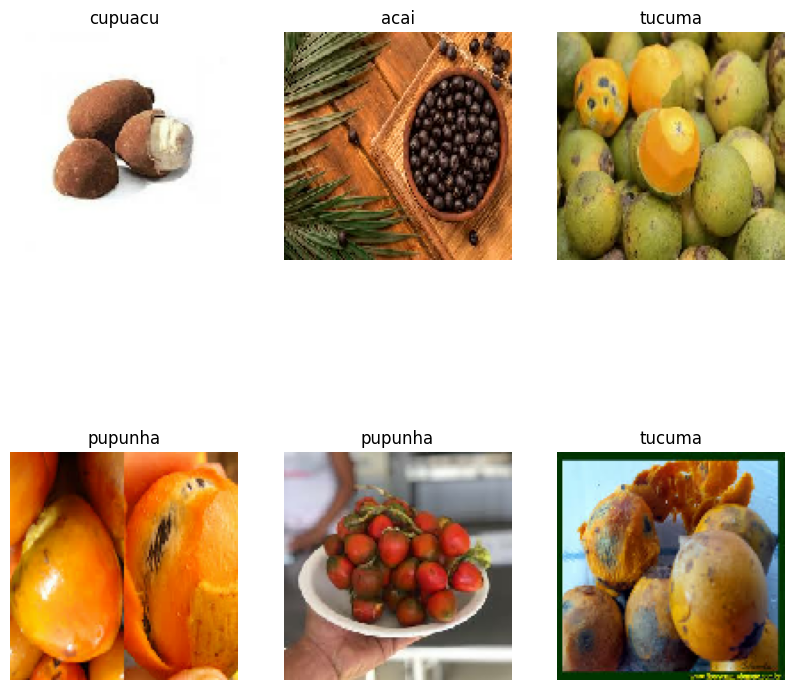

In [ ]:
# Grab the class names directly from your directory structure
# (Since the dataset was mapped, we pull them from the folders again)
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

# Set up a 10x10 figure
plt.figure(figsize=(10, 10))

# Take exactly one batch (32 images and labels) from the dataset
for images, labels in train_ds.take(1):
    # Loop through the first 9 images in that batch
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)

        # The images are already rescaled to [0, 1], so matplotlib can display them directly
        plt.imshow(images[i].numpy())

        # Match the integer label back to the actual class name
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

plt.show()

2. Check for Corrupted Image: Write a script that verifies whether the image in the train directory are valid. If any corrupted images are found, the script must remove the image from the directory and print the message which image have been removed, if none found print ”No Corrupted Images Found.”
* Hint:

  * Iterate through each class subdirectory and check if each image is valid
  * Use the Image.open() function to attempt to load each image.
  * If the image is corrupted i.e. raises an IOError or SyntaxError, remove the image from the directory and print f"Removed corrupted image: {image_path}".
  * Maintain a list of all corrupted image paths for reporting.
* Expected Output: No corrupted images found.

In [ ]:
corrupted_images = []

# Iterate through each class subdirectory
for root, dirs, files in os.walk(train_dir):
    for file in files:
        # Only check files that are supposed to be images
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
            img_path = os.path.join(root, file)

            # Attempt to load and catch errors
            try:
                with Image.open(img_path) as img:
                    img.verify() # This specifically checks for corruption/truncation
            except (IOError, SyntaxError) as e:
                # Remove image and print message
                corrupted_images.append(img_path)
                os.remove(img_path)
                print(f"Removed corrupted image: {img_path}")

# Final reporting
if not corrupted_images:
    print("No corrupted images found.")

No corrupted images found.


## Task 2: Loading and Preprocessing Image Data in keras:
In this section, we will load and preprocess image data from a directory using the image dataset from directory function in Keras.

This function is used to load images from a directory structure where subdirectories represent different
classes. We will also apply basic preprocessing, including resizing and batching and normalization of
images. The same function can be used to load train and validation data.

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=16,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

Found 90 files belonging to 6 classes.
Using 72 files for training.


## Task 3 - Implement a CNN with
Follow the following Structure and Hyper - parameters:
Convolutional Architecture:
* Convolutional Layer 1:
  * Filter Size (F): (3, 3)
  * Number of Filters (k): 32
  * Padding (P): same
  * Stride (s): 1
* Activation Layer: ReLU activation
* Pooling Layer 1: Max pooling
  * Filter Size (F): (2, 2)
  * Stride (s): 2
* Convolutional Layer 2:
  * Filter Size (F): (3, 3)
  * Number of Filters (k): 32
  * Padding (P): same
  * Stride (s): 1
* Activation Layer: ReLU activation
* Pooling Layer 2: Max pooling
  * Filter Size (F): (2, 2)
  * Stride (s): 2

Fully Connected Network Architecture:
  * Flatten Layer: Flatten the input coming from the convolutional layers
  * Input Layer:
  * Hidden Layer - 2:
    * Number of Neurons: 64
    * Number of Neurons: 128
  * Output Layer:
  * Number of Neurons: num classes (number of output classes)

In [ ]:
num_classes = 6

model = keras.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', strides=1,
                  activation='relu', input_shape=(img_height, img_width, 3)),

    layers.MaxPooling2D(pool_size=(2, 2), strides=2),
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', strides=1,
                  activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Compile the Model
Model Compilation
* Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

In [ ]:
model.compile(
optimizer="adam", # Stochastic Gradient Descent
loss='sparse_categorical_crossentropy', # Loss function for multi-class classification
metrics=["accuracy"] # Track accuracy during training
)

## Task 4: Train the Model
Model Training
* Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs
to 250.
* Use val ds for validation.

* Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoid-
ing overfitting.

In [ ]:
epochs = 250

# Callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=15),
]

# Train the model with callbacks and validation set
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 451ms/step - accuracy: 0.0972 - loss: 313.2074 - val_accuracy: 0.0000e+00 - val_loss: 2.4305
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 405ms/step - accuracy: 0.2917 - loss: 60.5676 - val_accuracy: 0.0000e+00 - val_loss: 1.8112
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 570ms/step - accuracy: 0.2639 - loss: 6.5057 - val_accuracy: 0.1111 - val_loss: 1.7939
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 333ms/step - accuracy: 0.4722 - loss: 1.4615 - val_accuracy: 0.0556 - val_loss: 1.7873
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 379ms/step - accuracy: 0.7083 - loss: 0.8879 - val_accuracy: 0.5556 - val_loss: 1.7811
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 336ms/step - accuracy: 0.8750 - loss: 0.7120 - val_accuracy: 0.8333 - val_loss: 1.7750
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 361ms/step - accuracy: 0.8889 - loss: 0.4303 - val_accuracy: 0.6667 - val_loss: 1.7668
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 370ms/step - accuracy: 0.9444 - loss: 0.2172 - val_accuracy:

## Task 5: Evaluate the Model
Model Evaluation
* After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [ ]:
print("Evaluating model on validation data...")
val_loss, val_accuracy = model.evaluate(val_ds)
print(f"Final Validation Loss: {val_loss:.4f}")
print(f"Final Validation Accuracy: {val_accuracy:.4f}")

Evaluating model on validation data...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9444 - loss: 1.6775
Final Validation Loss: 1.6775
Final Validation Accuracy: 0.9444


## Task 6: Save and Load the Model
Model Saving and Loading
* Save the trained model to an .h5 file using model.save().
* Load the saved model and re-evaluate its performance on the test set.

In [ ]:
model.save("/content/drive/MyDrive/Week1LastSem/FruitinAmazon_model.keras")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
loaded_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Week1LastSem/FruitinAmazon_model.keras"
)
print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
loaded_model.compile(
optimizer="adam", # Stochastic Gradient Descent
loss='sparse_categorical_crossentropy', # Loss function for multi-class classification
metrics=["accuracy"] # Track accuracy during training
)

In [ ]:
loss, accuracy = loaded_model.evaluate(val_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step - accuracy: 0.9444 - loss: 1.6775
Test Loss: 1.6775
Test Accuracy: 0.9444


## Task 7: Predictions and Classification Report
Making Predictions
* Use model.predict() to make predictions on test images.
* Convert the model’s predicted probabilities to digit labels using np.argmax().
* Also use from sklearn.metrics import classification report to report the Classification

Report of your Model Performance.

In [ ]:
# Predict probabilities
y_pred_probs = loaded_model.predict(val_ds)

# Convert probabilities into class label
y_pred = np.argmax(y_pred_probs, axis=1)

true_labels = np.concatenate([y.numpy() for x, y in val_ds], axis=0)

labels = np.unique(true_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 561ms/step


In [ ]:
report = classification_report(
    true_labels,
    y_pred,
    labels=labels,
    target_names=[class_names[i] for i in labels]
)

print(report)

              precision    recall  f1-score   support

     pupunha       1.00      0.67      0.80         3
      tucuma       0.94      1.00      0.97        15

    accuracy                           0.94        18
   macro avg       0.97      0.83      0.88        18
weighted avg       0.95      0.94      0.94        18

